In [1]:
import sys, os
sys.path.insert(0, os.path.join('..', 'src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from preprocessing import (
    load_yelp_reviews, preprocess_dataframe,
    get_tag_columns, train_val_test_split,
    build_restaurant_profiles, make_sample_dataset,
)

sns.set_theme(style='whitegrid')
%matplotlib inline

In [2]:
# real Yelp data 
REVIEWS_PATH   = '../data/yelp_academic_dataset_review.json'
BUSINESSES_PATH = '../data/yelp_academic_dataset_business.json'
USE_SAMPLE = not os.path.exists(REVIEWS_PATH)

if USE_SAMPLE:
    print('Yelp files not found — using synthetic sample dataset (2000 rows).')
    raw_df = make_sample_dataset(n=2000)
else:
    raw_df = load_yelp_reviews(REVIEWS_PATH, BUSINESSES_PATH, max_reviews=500_000)

print(raw_df.shape)
raw_df.head(3)

Loading businesses...


150346it [00:01, 146670.45it/s]


  64,577 restaurant businesses loaded.
Loading reviews...


681868it [00:02, 253284.79it/s]


  500,000 reviews loaded.
(500000, 11)


,review_id,business_id,stars,text,useful,name,city,state,stars_business,review_count,categories
0,KU_O5udG6zpxOg-VcAEodg,XQfwVwDr-v0ZS3_CbbE5Xw,3.0,"If you decide to eat here, just be aware it is...",0,Turning Point of North Wales,North Wales,PA,3.0,169,"Restaurants, Breakfast & Brunch, Food, Juice B..."
1,saUsX_uimxRlCVr67Z4Jig,YjUWPpI6HXG530lwP-fb2A,3.0,Family diner. Had the buffet. Eclectic assortm...,0,Kettle Restaurant,Tucson,AZ,3.5,47,"Restaurants, Breakfast & Brunch"
2,AqPFMleE6RsU23_auESxiA,kxX2SOes4o-D3ZQBkiMRfA,5.0,"Wow! Yummy, different, delicious. Our favo...",1,Zaika,Philadelphia,PA,4.0,181,"Halal, Pakistani, Restaurants, Indian"


In [3]:
df = preprocess_dataframe(raw_df)
df.to_parquet('../data/processed.parquet', index=False)
print('Saved to data/processed.parquet')
df.head(3)

Cleaning text...
Assigning sentiment labels...
Assigning tags...
Saved to data/processed.parquet


,review_id,business_id,stars,text,useful,name,city,state,stars_business,review_count,...,sentiment,tags,tag_quiet,tag_brunch,tag_date_night,tag_hidden_gem,tag_aesthetic,tag_family_friendly,tag_late_night,tag_trendy
0,KU_O5udG6zpxOg-VcAEodg,XQfwVwDr-v0ZS3_CbbE5Xw,3.0,"If you decide to eat here, just be aware it is...",0,Turning Point of North Wales,North Wales,PA,3.0,169,...,Neutral,[],0,0,0,0,0,0,0,0
1,saUsX_uimxRlCVr67Z4Jig,YjUWPpI6HXG530lwP-fb2A,3.0,Family diner. Had the buffet. Eclectic assortm...,0,Kettle Restaurant,Tucson,AZ,3.5,47,...,Neutral,"[Quiet, Brunch]",1,1,0,0,0,0,0,0
2,AqPFMleE6RsU23_auESxiA,kxX2SOes4o-D3ZQBkiMRfA,5.0,"Wow! Yummy, different, delicious. Our favo...",1,Zaika,Philadelphia,PA,4.0,181,...,Positive,[],0,0,0,0,0,0,0,0


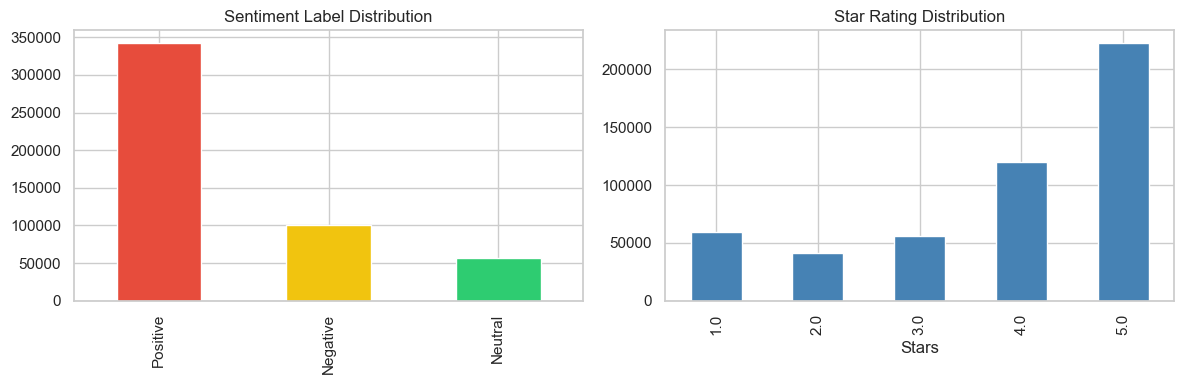

In [4]:
#sentiment distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['sentiment'].value_counts().plot(kind='bar', ax=axes[0], color=['#e74c3c','#f1c40f','#2ecc71'])
axes[0].set_title('Sentiment Label Distribution')
axes[0].set_xlabel('')

df['stars'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Star Rating Distribution')
axes[1].set_xlabel('Stars')
plt.tight_layout()
plt.savefig('../data/eda_sentiment_stars.png', dpi=150)
plt.show()

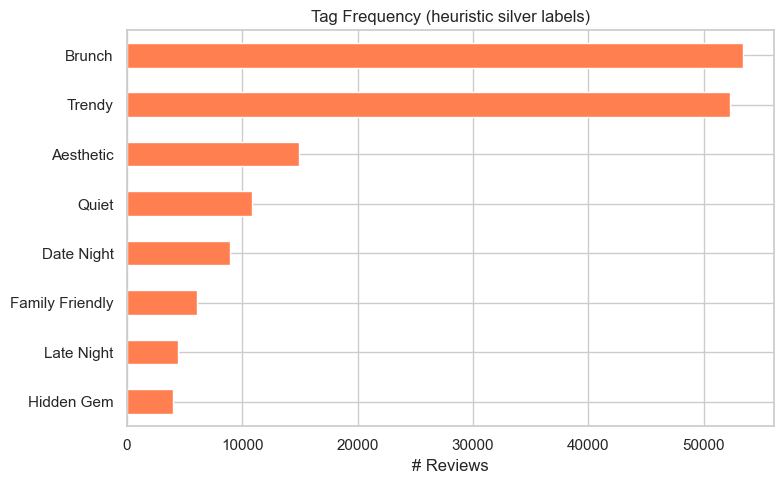

In [5]:
#tag frequency
tag_cols = get_tag_columns(df)
tag_freq = df[tag_cols].sum().sort_values(ascending=True)
tag_freq.index = [c.replace('tag_', '').replace('_', ' ').title() for c in tag_freq.index]

fig, ax = plt.subplots(figsize=(8, 5))
tag_freq.plot(kind='barh', ax=ax, color='coral')
ax.set_title('Tag Frequency (heuristic silver labels)')
ax.set_xlabel('# Reviews')
plt.tight_layout()
plt.savefig('../data/eda_tag_frequency.png', dpi=150)
plt.show()

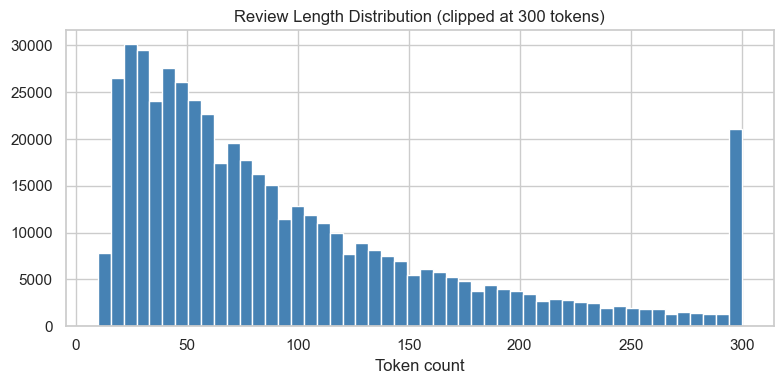

In [6]:
#review length distribution
df['text_len'] = df['text_clean'].str.split().str.len()
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df['text_len'].clip(upper=300), bins=50, color='steelblue', edgecolor='white')
ax.set_xlabel('Token count')
ax.set_title('Review Length Distribution (clipped at 300 tokens)')
plt.tight_layout()
plt.savefig('../data/eda_review_length.png', dpi=150)
plt.show()

In [7]:
#train / val / test split
train, val, test = train_val_test_split(df)
print(f'Train: {len(train):,}  Val: {len(val):,}  Test: {len(test):,}')

#persist splits
train.to_parquet('../data/train.parquet', index=False)
val.to_parquet('../data/val.parquet', index=False)
test.to_parquet('../data/test.parquet', index=False)
print('Splits saved.')

Train: 399,133  Val: 49,891  Test: 49,891
Splits saved.


In [ ]:
#restaurant profiles
profiles = build_restaurant_profiles(df)
profiles.to_parquet('../data/restaurant_profiles.parquet', index=False)
print(f'{len(profiles):,} restaurant profiles saved.')
profiles.head()

6,463 restaurant profiles saved.


,business_id,avg_stars,review_count,name,city,state,categories,tag_quiet,tag_brunch,tag_date_night,tag_hidden_gem,tag_aesthetic,tag_family_friendly,tag_late_night,tag_trendy,n_negative,n_neutral,n_positive,positive_ratio
0,--ZVrH2X2QXBFdCilbirsw,4.735294,32,Chris's Sandwich Shop,Ardmore,PA,"American (Traditional), Restaurants, Pizza, Sa...",0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.117647,0,3,31,0.911765
1,--hF_3v1JmU9nlu4zfXJ8Q,4.777778,15,Green District Salads - Monument Circle,Indianapolis,IN,"Vegetarian, Restaurants, Wraps, Salad",0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.222222,0,0,9,1.000000
2,-0Ym1Wg3bXd_TDz8JtvOQg,4.405941,105,Yelo'd Ice Cream,Edmonton,AB,"Food, Ice Cream & Frozen Yogurt, Bakeries",0.000000,0.059406,0.000000,0.0,0.029703,0.009901,0.009901,0.099010,5,8,88,0.871287
3,-0fvhILrC9UsQ6gLNpZlTQ,4.578947,18,David's Southern Fried Pies,Philadelphia,PA,"Desserts, Food",0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.368421,0,3,16,0.842105
4,-1MhPXk1FglglUAmuPLIGg,3.889908,107,Red Garter Saloon,Tucson,AZ,"Nightlife, Burgers, Sports Bars, Bars, Restaur...",0.055046,0.000000,0.009174,0.0,0.027523,0.009174,0.036697,0.073394,13,15,81,0.743119


: 